# **TP6 - Gaussian Mixture Model (GMM) & EM Algorithm**

<b>Exploratory Data Analysis & Unsuperivsed Learning </b><br>
**Course: Dr. HAS Sothea** <br> 
**TP: Ms. UANN Sreyvi**

-------

**Objective**: In this lab, we'll dive into the fascinating world of Gaussian Mixture Models (GMMs) and the Expectation-Maximization (EM) algorithm, both of which are fundamental concepts of unsupervised machine learning. GMMs can be viewed from various angles, such as density estimation and soft clustering. We'll explore both perspectives and apply it to image segmentation, laying the groundwork for a broader understanding of generative models.

---------

> **The `Jupyter Notebook` for this TP can be downloaded here: [TP6-GMM_EM](https://hassothea.github.io/EDA_ITC/TPs/TP6_GMM_EM.ipynb)**.

-------

## 1. Theory of 1D Gaussian Mixture Models

**A. Formulate Observed Objective Function of Mixture Model:** 

* If $x\in\mathbb{R}$, assume the following parameters:
    - $K = 3,$ and $(\pi_k)$ with $\sum_{k=1}^K\pi_k=1$, the proportion of group $k=1,\dots,K$.
    - $f_k(x)=\mathcal{N}(\mu_k, \sigma_k^2)$ for any $k=1,\dots,K$ with $\mu\in\mathbb{R}$ and $\sigma_k>0$. What includes in the parameter $\theta$ of this model? Write the explicit formula for likelihood function of this 1D GMM model for a given observation $\{x_1,\dots,x_n\}$: $$L_{\text{obs}}(\theta)=p(\theta|x_1,\dots,x_n)?$$
* Write the explicit formula for the corresponding observed log-likehood of this 1d GMM model: $$\mathcal{L}_{\text{obs}}(\theta)=p(\theta|x_1,\dots,x_n).$$

**B. Complete Log-Likelihood Function:**

* By introducing latent variables $Z_i=(z_{i1},\dots,z_{iK})\in \{0,1\}^K$ such that $\sum_{k=1}^Kz_{ik}=1$ with $Z_i|x_i\sim \mathcal{M}(\gamma_{i1},\dots,\gamma_{iK})$ for all $i=1,2,\dots,n$. What is the dimension of $\Gamma=(\gamma_{ik})?$ Write the explicit formula for the complete likelihood function for the observations $x_1,\dots,x_n$: $$L_{\text{com}}(\theta,\Gamma)=p(\theta,\Gamma|x_1,\dots,x_n,z_1,\dots,z_n).$$

* Write the complete log-likelihood function for this 1D GMM model: $$\mathcal{L}_{\text{com}}(\theta,\Gamma)=p(\theta,\Gamma|x_1,\dots,x_n,z_1,\dots,z_n).$$

**C. Explicit ELBO:**

* Check the **Evidence**, **ELBO** and **KL divergence**.

* Write explicit formula for each term in 1D GMM case.

## 2. Gaussian Mixture Models

**A.** Perform GMM using `GaussianMixture` from `sklearn.mixture` on `Iris` dataset using `n_components=5`. 

Read this [documentation](https://scikit-learn.org/1.5/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture) and answer the followign questions:

- Print the estimated parameters of each component.
- What does the `score()` do in this module?
- Compute this `score`, `AIC` and `BIC` of the trained GMM.


In [19]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris['data']
X.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2


In [13]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=82)
gmm.fit(X)

X['cluster'] = gmm.predict(X)
params = gmm.get_params(deep=True)
print(params)

{'covariance_type': 'full', 'init_params': 'kmeans', 'max_iter': 100, 'means_init': None, 'n_components': 5, 'n_init': 1, 'precisions_init': None, 'random_state': 82, 'reg_covar': 1e-06, 'tol': 0.001, 'verbose': 0, 'verbose_interval': 10, 'warm_start': False, 'weights_init': None}


In [14]:
log_likelihood = gmm.score(X)
print("Average log-likelihood per sample:", log_likelihood)

Average log-likelihood per sample: -11.443385305710809


In [15]:
aic = gmm.aic(X)
bic = gmm.bic(X)

print(f'AIC = {aic}, BIC = {bic}')

AIC = 3641.0155917132424, BIC = 3954.121662299253


**B.** Perform GMM on `Iris` data but this time using `n_components = 1,2,...,10`.

- Compute the `score, AIC` and `BIC` at each number of component.
- What is the optimal number of component.

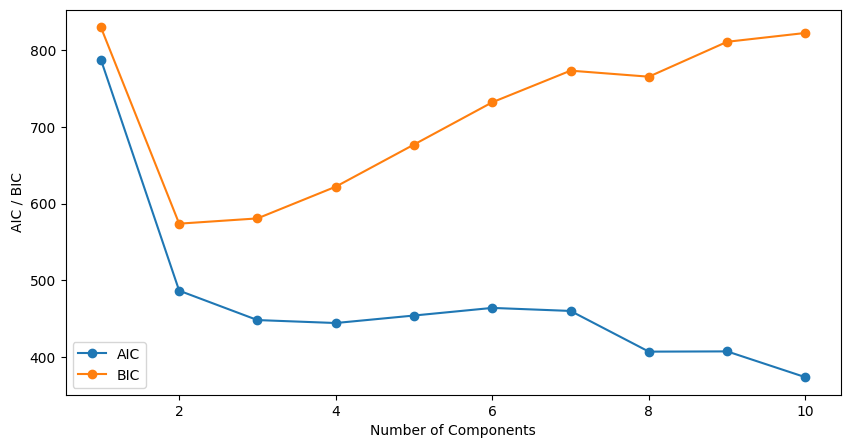

In [51]:
metrics = []
for i in range(1, 11):
    gmm = GaussianMixture(n_components=i)
    gmm.fit(X)
    score = gmm.score(X)
    aic = gmm.aic(X)
    bic = gmm.bic(X)
    metrics.append({'n_components' : i, 'score' : score, 'aic' : aic, 'bic' : bic})

import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame(metrics)

plt.figure(figsize=(10,5))
plt.plot(metrics_df['n_components'], metrics_df['aic'], label='AIC', marker='o')
plt.plot(metrics_df['n_components'], metrics_df['bic'], label='BIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('AIC / BIC')
plt.legend()
plt.show()


**C.** With the optimal number of components from question **B**, perform GMM on `Iris` data using different options of `covariance_type` from the list ['full', 'tied', 'diag', 'spherical']. In each case, compute the score associated to each variance type. Comment.

In [ ]:
# To do

**D.** Repeat question **B** and **C** on a simulated data from the [previous `TP5`](https://hassothea.github.io/EDA_ITC/TPs/TP5_Clustering.html). How is GMM's result compared to Kmeans or Hierarchical clustering?

In [ ]:
# To do

## 3. EM Algorithm

The EM algorithm is used to estimate the parameters of the GMM, ensuring that the model fits the data as closely as possible by iteratively refining the parameters. It leverages the concept of latent variables (responsibilities) to handle the fact that the actual class labels for the data points are unknown.

This iterative optimization makes GMMs a powerful tool for tasks like clustering and density estimation.

**A.** Recall the process of EM algorithm in GMM of $K$ components.

> To do

**B. 1D EM Algorithm**:

- Plot the density of the third column of `Iris` dataset. From this density, what is the number of components?
- Write a function `EM1d(x, K=3, max_iter = 100)` that takes 1D data array `x`, number of components `K` and the maximum itermation of EM algorithm `max_iter`. The function should return: `responsibility matrix` $\Gamma$, `center` and `variance` of all $K$ components.
- Apply your function to the third column of the iris data with $K=1,2,...,10$.
- Compute `score`, `AIC` and `BIC` for each $K$ (you may need to write your own function for that). What is the optimal number of components?
- Visualize your estimated density.

In [15]:
# To do

**C. Image Segmentation.** 

- Load any image (not too large resolution or it can be an `Mnist` image from the previous TP).
- Reshape it into 1D array, then apply your `EM1d` function (or sklearn GMM function) on that 1D pixel array with your desired number of components.
- Assign each pixel to a component and reshape the segmented image back into its original shape.
- Display the original and segmented images side by side. Comment.

In [14]:
# To do

# Further Readings

- [GaussianMixture, sklearn](https://scikit-learn.org/1.5/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture)
- [Gaussian Mixture Models and EM, Ch. 9, Pattern Recognition and Machine Learning, Christopher M. Bishop](https://www.cs.columbia.edu/~verma/classes/ml/ref/lec7_prmlMixturesEM.pdf)
- [Gaussian Mixture Models (GMM), Juliette Chevallier](https://juliette-chevallier.pages.math.cnrs.fr/doc/4MA/Data_Analysis/Gaussian_Mixture_Models.pdf)